# Fish Toxicity Data Cleaning

In this notebook I will be cleaning the QSAR fish 
toxicity dataset based on what I found during the 
exploration phase. Since there were no missing values 
I will mainly be focusing on handling outliers and 
saving the cleaned dataset.

## Importing Libraries
Here I am importing the libraries I will need
for the cleaning process.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Loading the Data
Here I am loading the raw dataset again to 
begin the cleaning process.

In [34]:
# defining column names
columns = ['CIC0', 'SM1_Dz', 'GATS1i', 'NdsCH', 'NdssC', 'MLOGP', 'LC50']

# loading the raw dataset
df = pd.read_csv('../data/qsar_fish_toxicity.csv', 
                  sep=';',
                  names=columns)
# checking it loaded correctly
df.head()

,CIC0,SM1_Dz,GATS1i,NdsCH,NdssC,MLOGP,LC50
0,3.260,0.829,1.676,0,1,1.453,3.770
1,2.189,0.580,0.863,0,0,1.348,3.115
2,2.125,0.638,0.831,0,0,1.348,3.531
3,3.027,0.331,1.472,1,0,1.807,3.510
4,2.094,0.827,0.860,0,0,1.886,5.390


## Verifying Missing Values
Here I am double checking for missing values 
before I start cleaning.

In [35]:
# checking for missing values
# confirmed no missing values from explore phase
df.isnull().sum()

CIC0      0
SM1_Dz    0
GATS1i    0
NdsCH     0
NdssC     0
MLOGP     0
LC50      0
dtype: int64

## Checking Data Types
Here I am verifying that all columns are the 
correct data type before cleaning. All columns 
need to be numerical for linear regression 
to work properly.


In [36]:
df.dtypes

CIC0      float64
SM1_Dz    float64
GATS1i    float64
NdsCH       int64
NdssC       int64
MLOGP     float64
LC50      float64
dtype: object

## Detecting Outliers with Z Score
Here I am using the Z Score method to detect 
outliers.

In [37]:
z_scores = np.abs(stats.zscore(df))
# counting how many outliers exist per column
# anything with z score above 3 is an outlier
print('Outliers detected per column:')
print((z_scores > 3).sum())

Outliers detected per column:
43


## Removing Outliers with Z Score
Here I am removing all rows where any column 
has a Z Score above 3.

In [38]:
# keeping only rows where all columns
# have a z score below 3
df_clean = df[(z_scores < 3).all(axis=1)]
# checking how many rows were removed
print(f'original shape: {df.shape}')
print(f'cleaned shape:  {df_clean.shape}')
print(f'rows removed:   {df.shape[0] - df_clean.shape[0]}')

original shape: (908, 7)
cleaned shape:  (869, 7)
rows removed:   39


## Verifying Outlier Removal
Here I am verifying the outlier removal by 
checking the boxplots again after cleaning 
and comparing them to the boxplots from 
the exploration phase.

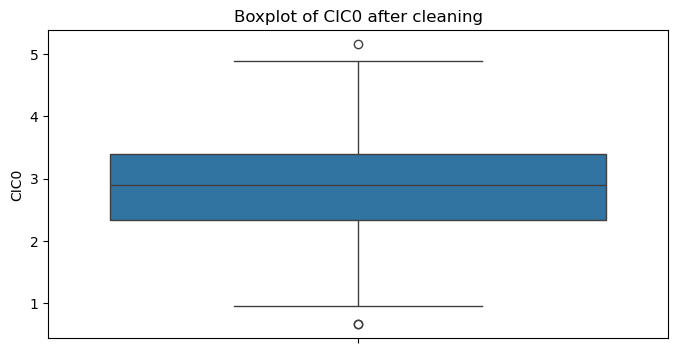

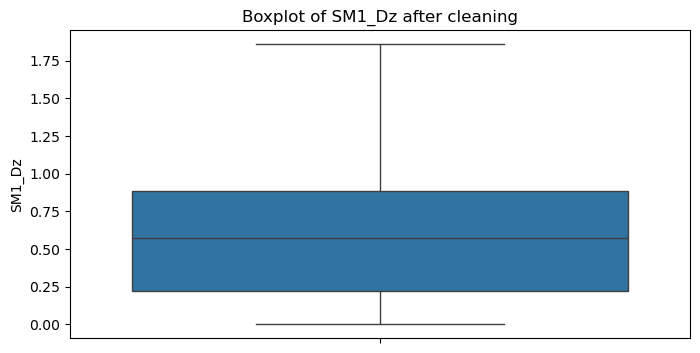

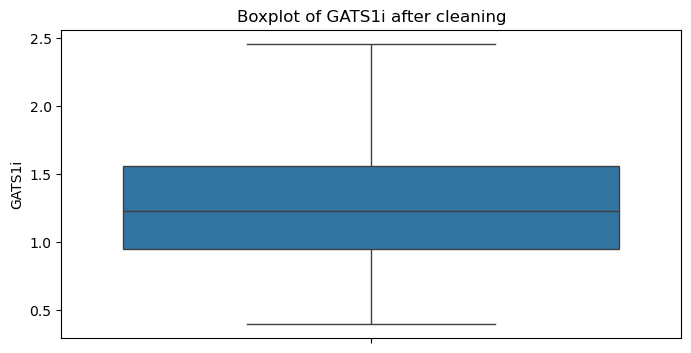

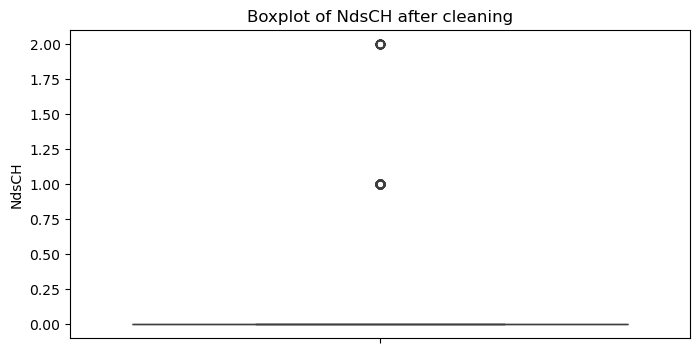

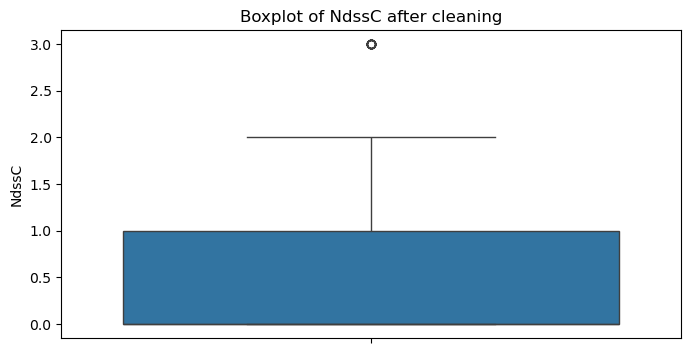

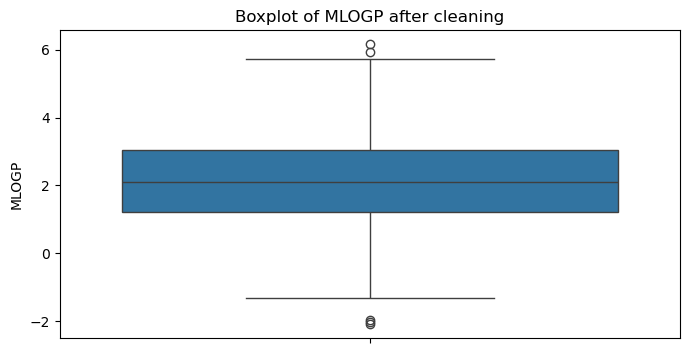

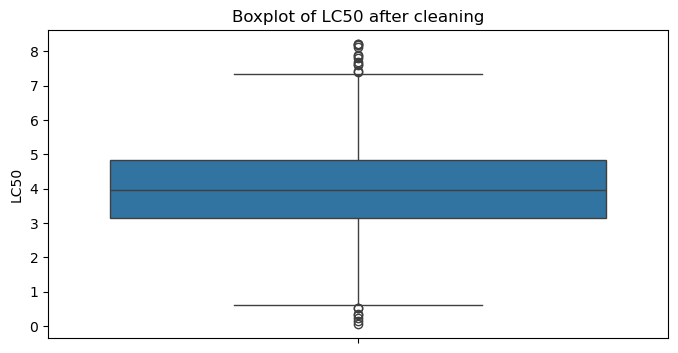

In [39]:
# checking boxplots after cleaning
# comparing to boxplots from explore phase
for column in df_clean.columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(df_clean[column])
    plt.title(f'Boxplot of {column} after cleaning')
    plt.show()

## Comparing Before and After
Here I am comparing the summary statistics 
before and after cleaning to see how the 
data changed.

In [40]:
# summary statistics before cleaning
print('Before Cleaning:')
print(df.describe())

Before Cleaning:
             CIC0      SM1_Dz      GATS1i       NdsCH       NdssC       MLOGP  \
count  908.000000  908.000000  908.000000  908.000000  908.000000  908.000000   
mean     2.898129    0.628468    1.293591    0.229075    0.485683    2.109285   
std      0.756088    0.428459    0.394303    0.605335    0.861279    1.433181   
min      0.667000    0.000000    0.396000    0.000000    0.000000   -2.884000   
25%      2.347000    0.223000    0.950750    0.000000    0.000000    1.209000   
50%      2.934000    0.570000    1.240500    0.000000    0.000000    2.127000   
75%      3.407000    0.892750    1.562250    0.000000    1.000000    3.105000   
max      5.926000    2.171000    2.920000    4.000000    6.000000    6.515000   

             LC50  
count  908.000000  
mean     4.064431  
std      1.455698  
min      0.053000  
25%      3.151750  
50%      3.987500  
75%      4.907500  
max      9.612000  


In [41]:
# summary statistics after cleaning
print('After Cleaning:')
print(df_clean.describe())


After Cleaning:
             CIC0      SM1_Dz      GATS1i       NdsCH       NdssC       MLOGP  \
count  869.000000  869.000000  869.000000  869.000000  869.000000  869.000000   
mean     2.876022    0.619486    1.285293    0.181818    0.425777    2.086591   
std      0.739597    0.415276    0.379447    0.462004    0.729925    1.390805   
min      0.667000    0.000000    0.396000    0.000000    0.000000   -2.089000   
25%      2.330000    0.223000    0.950000    0.000000    0.000000    1.209000   
50%      2.893000    0.570000    1.227000    0.000000    0.000000    2.110000   
75%      3.389000    0.887000    1.562000    0.000000    1.000000    3.045000   
max      5.158000    1.860000    2.456000    2.000000    3.000000    6.166000   

             LC50  
count  869.000000  
mean     4.010064  
std      1.374528  
min      0.053000  
25%      3.133000  
50%      3.971000  
75%      4.832000  
max      8.207000  


## Saving the Cleaned Dataset
Here I am saving the cleaned dataset to a new 
CSV file in the data folder. This cleaned dataset 
will be used in the modeling phase.

In [42]:
# saving the cleaned dataset to the data folder
# index=False means we dont save the row numbers
df_clean.to_csv('../data/clean_fish_toxicity.csv', index=False)


In [43]:
# confirming the file was saved
print('cleaned dataset saved successfully!')
print(f'final shape: {df_clean.shape}')


cleaned dataset saved successfully!
final shape: (869, 7)


## After cleaning the dataset I found:
- There were no missing values to handle
- All columns were already the correct data type
  so no type conversions were needed
- I used the Z Score method to detect and 
  remove outliers
- Any row where a value was more than 3 
  standard deviations from the mean 
  was removed as an outlier
- The dataset went from 908 rows to a smaller
  cleaner dataset after outlier removal
- The boxplots after cleaning confirmed that 
  the outliers were successfully removed
- The cleaned dataset has been saved to the 
  data folder as clean_fish_toxicity.csv 
  and is ready for modeling